In [1]:
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# --------------------------------------------------
# 1. Load ML-ready dataset
# --------------------------------------------------



DATA_PATH = (
    r"C:\Users\HP\Documents\finrisk\data\raw\finrisk_ml_dataset.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

# --------------------------------------------------
# 2. Separate target and identifier columns
# --------------------------------------------------

TARGET_COLUMN = "target"

ID_COLUMNS = [
    "loan_id",
    "borrower_id"
]

X = df.drop(columns=[TARGET_COLUMN] + ID_COLUMNS)
y = df[TARGET_COLUMN]

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

# --------------------------------------------------
# 3. Remove columns that are completely empty
# --------------------------------------------------

empty_columns = X.columns[X.isna().all()].tolist()

print("\nCompletely empty columns:")
print(empty_columns)

X = X.drop(columns=empty_columns)

print("\nFeature matrix after removing empty columns:", X.shape)

# --------------------------------------------------
# 4. Train-test split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain feature shape:", X_train.shape)
print("Test feature shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

# --------------------------------------------------
# 5. Identify numeric and categorical columns
# --------------------------------------------------

numeric_columns = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    exclude=["number"]
).columns.tolist()

print("\nNumeric columns:", len(numeric_columns))
print("Categorical columns:", len(categorical_columns))

print("\nCategorical column names:")
print(categorical_columns)

Dataset shape: (1303638, 73)

Feature matrix shape: (1303638, 70)
Target shape: (1303638,)

Target distribution:
target
0    1041952
1     261686
Name: count, dtype: int64

Completely empty columns:
[]

Feature matrix after removing empty columns: (1303638, 70)

Train feature shape: (1042910, 70)
Test feature shape: (260728, 70)

Train target distribution:
target
0    79.93
1    20.07
Name: proportion, dtype: float64

Test target distribution:
target
0    79.93
1    20.07
Name: proportion, dtype: float64

Numeric columns: 70
Categorical columns: 0

Categorical column names:
[]


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# --------------------------------------------------
# 1. Load ML-ready dataset
# --------------------------------------------------



DATA_PATH = (
    r"C:\Users\HP\Documents\finrisk\data\raw\finrisk_ml_dataset.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

# --------------------------------------------------
# 2. Separate target and identifier columns
# --------------------------------------------------

TARGET_COLUMN = "target"

ID_COLUMNS = [
    "loan_id",
    "borrower_id"
]

X = df.drop(columns=[TARGET_COLUMN] + ID_COLUMNS)
y = df[TARGET_COLUMN]

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

# --------------------------------------------------
# 3. Replace infinite values with NaN
# --------------------------------------------------

X = X.replace([np.inf, -np.inf], np.nan)

print("\nTotal missing values before preprocessing:")
print(X.isna().sum().sum())

# --------------------------------------------------
# 4. Train-test split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain feature shape:", X_train.shape)
print("Test feature shape:", X_test.shape)

# --------------------------------------------------
# 5. Create preprocessing pipeline
# --------------------------------------------------

preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# --------------------------------------------------
# 6. Fit only on training data
# --------------------------------------------------

X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the already-fitted pipeline
X_test_processed = preprocessor.transform(X_test)

# --------------------------------------------------
# 7. Check processed data
# --------------------------------------------------

print("\nProcessed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

print("\nMissing values in processed train:")
print(np.isnan(X_train_processed).sum())

print("\nMissing values in processed test:")
print(np.isnan(X_test_processed).sum())

print("\nMean of first five processed features:")
print(X_train_processed[:, :5].mean(axis=0).round(4))

print("\nStandard deviation of first five processed features:")
print(X_train_processed[:, :5].std(axis=0).round(4))

Dataset shape: (1303638, 73)

Feature matrix shape: (1303638, 70)
Target shape: (1303638,)

Total missing values before preprocessing:
2

Train feature shape: (1042910, 70)
Test feature shape: (260728, 70)

Processed train shape: (1042910, 70)
Processed test shape: (260728, 70)

Missing values in processed train:
0

Missing values in processed test:
0

Mean of first five processed features:
[ 0. -0. -0.  0. -0.]

Standard deviation of first five processed features:
[1. 1. 1. 1. 1.]


In [3]:
solver="saga"
max_iter=100

In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     roc_auc_score,
#     average_precision_score,
#     confusion_matrix,
#     classification_report
# )


# # Train Logistic Regression baseline


# print("\nTraining Logistic Regression...")

# logistic_model = LogisticRegression(
#     class_weight="balanced",
#     solver="saga",
#     max_iter=100,
#     random_state=42,
#     n_jobs=-1
# )

# logistic_model.fit(
#     X_train_processed,
#     y_train
# )

# print("Logistic Regression training completed.")


# #  Generate predictions


# y_pred = logistic_model.predict(X_test_processed)

# y_prob = logistic_model.predict_proba(
#     X_test_processed
# )[:, 1]


#  10. Evaluate model


# accuracy = accuracy_score(y_test, y_pred)

# precision = precision_score(
#     y_test,
#     y_pred,
#     zero_division=0
# )

# recall = recall_score(
#     y_test,
#     y_pred,
#     zero_division=0
# )

# f1 = f1_score(
#     y_test,
#     y_pred,
#     zero_division=0
# )

# roc_auc = roc_auc_score(
#     y_test,
#     y_prob
# )

# pr_auc = average_precision_score(
#     y_test,
#     y_prob
# )

# print("\n========== Logistic Regression Results ==========")

# print(f"Accuracy:  {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall:    {recall:.4f}")
# print(f"F1 Score:  {f1:.4f}")
# print(f"ROC-AUC:   {roc_auc:.4f}")
# print(f"PR-AUC:    {pr_auc:.4f}")

# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred))

# print("\nClassification Report:")
# print(
#     classification_report(
#         y_test,
#         y_pred,
#         target_names=["Non-default", "Default"],
#         zero_division=0
#     )
# ) /// need revision 

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)


# Train Logistic Regression baseline


print("\nTraining Logistic Regression...")

logistic_model = LogisticRegression(
    class_weight="balanced",
    solver="saga",
    max_iter=300,
    tol=1e-3,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression training completed.")


# Predictions

y_pred = logistic_model.predict(X_test_processed)

y_prob = logistic_model.predict_proba(
    X_test_processed
)[:, 1]


# Evaluation


print("\n========== Logistic Regression Results ==========")

print(
    f"Accuracy:  "
    f"{accuracy_score(y_test, y_pred):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test, y_pred, zero_division=0):.4f}"
)

print(
    f"Recall:    "
    f"{recall_score(y_test, y_pred, zero_division=0):.4f}"
)

print(
    f"F1 Score:  "
    f"{f1_score(y_test, y_pred, zero_division=0):.4f}"
)

print(
    f"ROC-AUC:   "
    f"{roc_auc_score(y_test, y_prob):.4f}"
)

print(
    f"PR-AUC:    "
    f"{average_precision_score(y_test, y_prob):.4f}"
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-default", "Default"],
        zero_division=0
    )
)


Training Logistic Regression...
Logistic Regression training completed.

========== Logistic Regression Results ==========
Accuracy:  0.6602
Precision: 0.3257
Recall:    0.6474
F1 Score:  0.4334
ROC-AUC:   0.7129
PR-AUC:    0.3739

Confusion Matrix:
[[138243  70148]
 [ 18456  33881]]

Classification Report:
              precision    recall  f1-score   support

 Non-default       0.88      0.66      0.76    208391
     Default       0.33      0.65      0.43     52337

    accuracy                           0.66    260728
   macro avg       0.60      0.66      0.60    260728
weighted avg       0.77      0.66      0.69    260728



Random Forest

In [7]:
from sklearn.ensemble import RandomForestClassifier

print("\nTraining Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

# --------------------------------------------------
# Predictions
# --------------------------------------------------

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(
    X_test
)[:, 1]

# --------------------------------------------------
# Evaluation
# --------------------------------------------------

print("\n========== Random Forest Results ==========")

print(
    f"Accuracy:  "
    f"{accuracy_score(y_test, rf_pred):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test, rf_pred, zero_division=0):.4f}"
)

print(
    f"Recall:    "
    f"{recall_score(y_test, rf_pred, zero_division=0):.4f}"
)

print(
    f"F1 Score:  "
    f"{f1_score(y_test, rf_pred, zero_division=0):.4f}"
)

print(
    f"ROC-AUC:   "
    f"{roc_auc_score(y_test, rf_prob):.4f}"
)

print(
    f"PR-AUC:    "
    f"{average_precision_score(y_test, rf_prob):.4f}"
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Non-default", "Default"],
        zero_division=0
    )
)


Training Random Forest...
Random Forest training completed.

========== Random Forest Results ==========
Accuracy:  0.6530
Precision: 0.3227
Recall:    0.6629
F1 Score:  0.4340
ROC-AUC:   0.7156
PR-AUC:    0.3814

Confusion Matrix:
[[135557  72834]
 [ 17643  34694]]

Classification Report:
              precision    recall  f1-score   support

 Non-default       0.88      0.65      0.75    208391
     Default       0.32      0.66      0.43     52337

    accuracy                           0.65    260728
   macro avg       0.60      0.66      0.59    260728
weighted avg       0.77      0.65      0.69    260728



In [8]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, rf_prob)
    ]
})

print("\n========== Model Comparison ==========")
print(comparison.round(4))


========== Model Comparison ==========
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  PR-AUC
0  Logistic Regression    0.6602     0.3257  0.6474    0.4334   0.7129  0.3739
1        Random Forest    0.6530     0.3227  0.6629    0.4340   0.7156  0.3814


<Figure size 800x600 with 0 Axes>

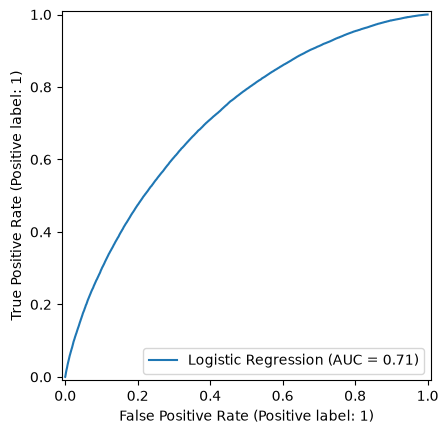

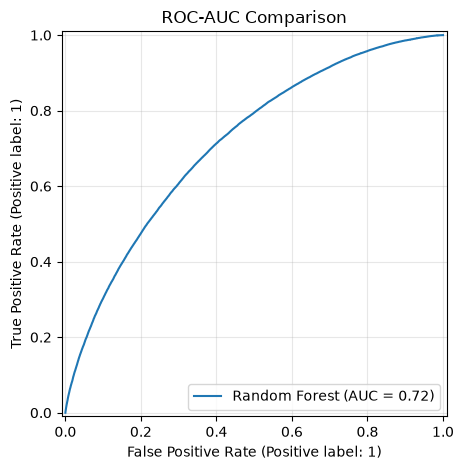

Saved ROC curve: C:\Users\HP\Documents\finrisk\roc_auc_comparison.png


<Figure size 800x600 with 0 Axes>

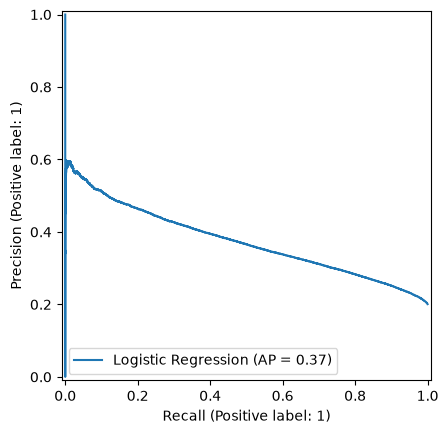

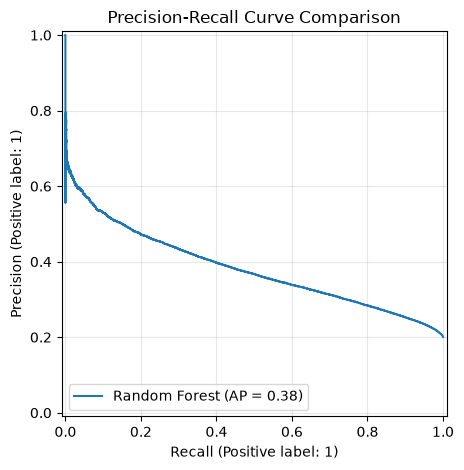

Saved Precision-Recall curve: C:\Users\HP\Documents\finrisk\precision_recall_comparison.png


In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# --------------------------------------------------
# 1. ROC-AUC curves
# --------------------------------------------------

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

plt.title("ROC-AUC Comparison")
plt.grid(alpha=0.3)
plt.tight_layout()

roc_path = r"C:\Users\HP\Documents\finrisk\roc_auc_comparison.png"
plt.savefig(roc_path, dpi=300)
plt.show()

print("Saved ROC curve:", roc_path)

# --------------------------------------------------
# 2. Precision-Recall curves
# --------------------------------------------------

plt.figure(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob,
    name="Logistic Regression"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

plt.title("Precision-Recall Curve Comparison")
plt.grid(alpha=0.3)
plt.tight_layout()

pr_path = r"C:\Users\HP\Documents\finrisk\precision_recall_comparison.png"
plt.savefig(pr_path, dpi=300)
plt.show()

print("Saved Precision-Recall curve:", pr_path)


========== Features Associated With Higher Default Risk ==========
             Feature  Coefficient  Odds_Ratio
            int_rate     0.488502    1.629873
         funded_amnt     0.296297    1.344870
           loan_amnt     0.282511    1.326456
     funded_amnt_inv     0.218988    1.244817
                 dti     0.159938    1.173438
acc_open_past_24mths     0.135489    1.145096
 mths_credit_history     0.133777    1.143138
   total_bal_ex_mort     0.123530    1.131484
         delinq_2yrs     0.101305    1.106614
    percent_bc_gt_75     0.082473    1.085969
     num_actv_rev_tl     0.068086    1.070457
  num_tl_op_past_12m     0.065098    1.067264
         open_il_24m     0.056300    1.057915
  mths_since_rcnt_il     0.050640    1.051944
         num_bc_sats     0.050549    1.051848

========== Features Associated With Lower Default Risk ==========
                   Feature  Coefficient  Odds_Ratio
               installment    -0.590849    0.553857
            total_bc_limi

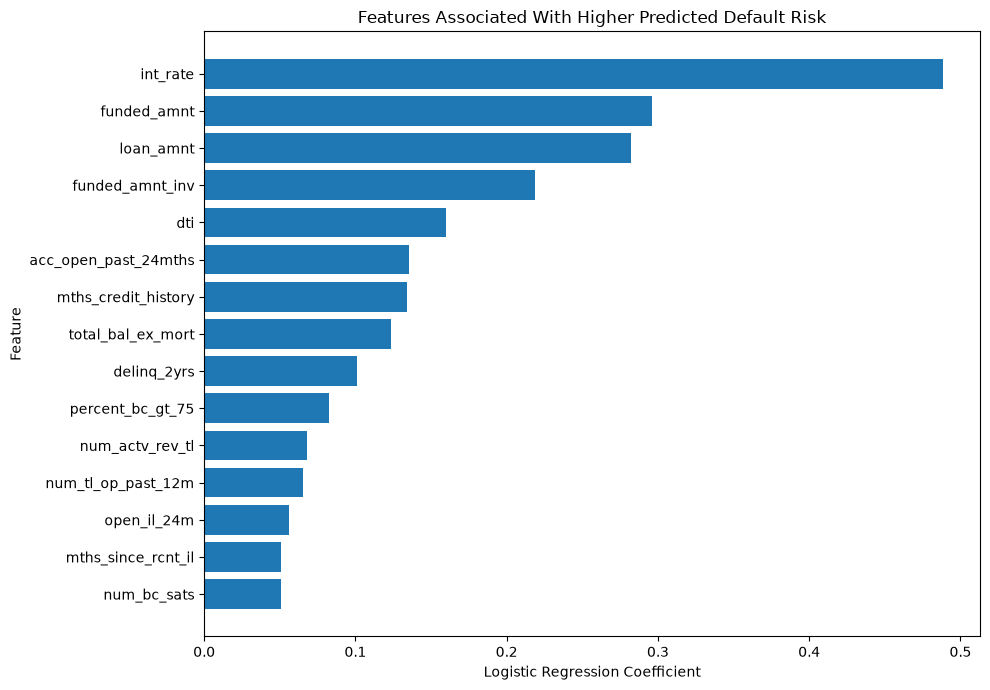

Saved positive coefficient plot: C:\Users\HP\Documents\finrisk\notebooks\logistic_positive_coefficients.png


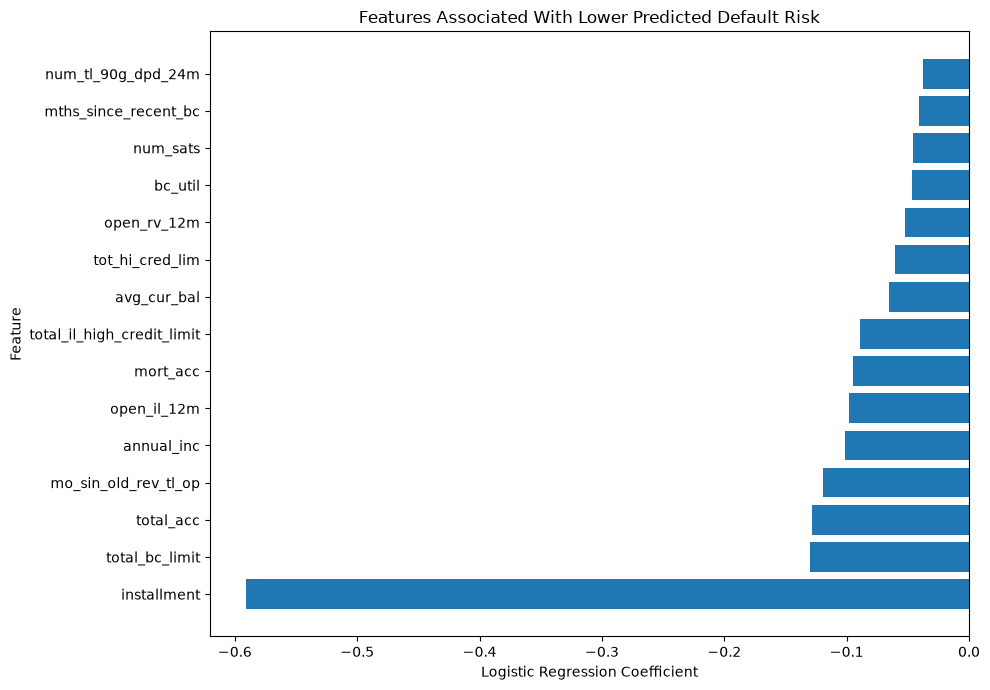

Saved negative coefficient plot: C:\Users\HP\Documents\finrisk\notebooks\logistic_negative_coefficients.png


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# Logistic Regression coefficients
# --------------------------------------------------

logistic_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

# Convert coefficients into odds ratios
logistic_coefficients["Odds_Ratio"] = np.exp(
    logistic_coefficients["Coefficient"]
)

# Sort by coefficient
logistic_coefficients = logistic_coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print("\n========== Features Associated With Higher Default Risk ==========")
print(
    logistic_coefficients.head(15).to_string(index=False)
)

print("\n========== Features Associated With Lower Default Risk ==========")
print(
    logistic_coefficients.tail(15)
    .sort_values(by="Coefficient")
    .to_string(index=False)
)

# --------------------------------------------------
# Save coefficient table
# --------------------------------------------------

coefficient_path = (
    r"C:\Users\HP\Documents\finrisk\notebooks\modelTraing.ipynb"
)

logistic_coefficients.to_csv(
    coefficient_path,
    index=False
)

print("\nSaved coefficient table:", coefficient_path)

# --------------------------------------------------
# Plot strongest positive coefficients
# --------------------------------------------------

positive_coefficients = (
    logistic_coefficients
    .head(15)
    .sort_values(by="Coefficient", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    positive_coefficients["Feature"],
    positive_coefficients["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Features Associated With Higher Predicted Default Risk")
plt.tight_layout()

positive_plot_path = (
    r"C:\Users\HP\Documents\finrisk\notebooks\logistic_positive_coefficients.png"
)

plt.savefig(positive_plot_path, dpi=300)
plt.show()

print("Saved positive coefficient plot:", positive_plot_path)

# --------------------------------------------------
# Plot strongest negative coefficients
# --------------------------------------------------

negative_coefficients = (
    logistic_coefficients
    .tail(15)
    .sort_values(by="Coefficient", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    negative_coefficients["Feature"],
    negative_coefficients["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Features Associated With Lower Predicted Default Risk")
plt.tight_layout()

negative_plot_path = (
    r"C:\Users\HP\Documents\finrisk\notebooks\logistic_negative_coefficients.png"
)

plt.savefig(negative_plot_path, dpi=300)
plt.show()

print("Saved negative coefficient plot:", negative_plot_path)

Higher interest rate was positively associated with predicted default risk in the Logistic Regression model.

In [14]:
import json

model_summary = {
    "project": "FinRisk",
    "task": "Binary loan-default classification",
    "target": {
        "0": "Fully Paid",
        "1": "Charged Off or Default"
    },
    "dataset": {
        "rows": int(df.shape[0]),
        "features": int(X.shape[1]),
        "train_rows": int(X_train.shape[0]),
        "test_rows": int(X_test.shape[0])
    },
    "models": {
        "Logistic Regression": {
            "accuracy": round(
                accuracy_score(y_test, y_pred), 4
            ),
            "precision": round(
                precision_score(
                    y_test,
                    y_pred,
                    zero_division=0
                ), 4
            ),
            "recall": round(
                recall_score(
                    y_test,
                    y_pred,
                    zero_division=0
                ), 4
            ),
            "f1_score": round(
                f1_score(
                    y_test,
                    y_pred,
                    zero_division=0
                ), 4
            ),
            "roc_auc": round(
                roc_auc_score(y_test, y_prob), 4
            ),
            "pr_auc": round(
                average_precision_score(y_test, y_prob), 4
            )
        },
        "Random Forest": {
            "accuracy": round(
                accuracy_score(y_test, rf_pred), 4
            ),
            "precision": round(
                precision_score(
                    y_test,
                    rf_pred,
                    zero_division=0
                ), 4
            ),
            "recall": round(
                recall_score(
                    y_test,
                    rf_pred,
                    zero_division=0
                ), 4
            ),
            "f1_score": round(
                f1_score(
                    y_test,
                    rf_pred,
                    zero_division=0
                ), 4
            ),
            "roc_auc": round(
                roc_auc_score(y_test, rf_prob), 4
            ),
            "pr_auc": round(
                average_precision_score(y_test, rf_prob), 4
            )
        }
    }
}

summary_path = r"C:\Users\HP\Documents\finrisk\notebooks\model_summary.json"

with open(summary_path, "w") as file:
    json.dump(
        model_summary,
        file,
        indent=4
    )

print("\nSaved model summary:", summary_path)


Saved model summary: C:\Users\HP\Documents\finrisk\notebooks\model_summary.json


Threshold analysis 

In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

# --------------------------------------------------
# Use Random Forest probabilities
# --------------------------------------------------

# Probability of class 1 = risky loan
y_test_prob = rf_model.predict_proba(X_test)[:, 1]

# --------------------------------------------------
# Evaluate multiple thresholds
# --------------------------------------------------

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

results = []

for threshold in thresholds:

    # Convert probability into predicted class
    y_pred_threshold = (y_test_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_test,
        y_pred_threshold
    )

    results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    })

# --------------------------------------------------
# Display results
# --------------------------------------------------

threshold_results = pd.DataFrame(results)

print("\nThreshold Analysis:")
print(threshold_results.round(4).to_string(index=False))

# --------------------------------------------------
#  Save results
# --------------------------------------------------

threshold_results.to_csv(
    r"C:\Users\HP\Documents\finrisk\notebooks\threshold_analysis.csv",
    index=False
)

print("\nThreshold analysis saved successfully.")


Threshold Analysis:
 threshold  accuracy  precision  recall  f1_score  true_negatives  false_positives  false_negatives  true_positives
       0.2    0.2361     0.2075  0.9953    0.3434            9469           198922              247           52090
       0.3    0.3447     0.2296  0.9616    0.3707           39542           168849             2010           50327
       0.4    0.5033     0.2681  0.8525    0.4080           86607           121784             7718           44619
       0.5    0.6530     0.3227  0.6629    0.4340          135557            72834            17643           34694
       0.6    0.7606     0.4010  0.3904    0.3956          177868            30523            31905           20432
       0.7    0.8004     0.5112  0.1254    0.2014          202116             6275            45775            6562
       0.8    0.7998     0.6535  0.0054    0.0107          208242              149            52056             281

Threshold analysis saved successfully.


Threshold analysis demonstrated a clear trade-off between precision and recall. Lower classification thresholds improved recall and captured more risky loans but increased false positives. Higher thresholds improved precision but resulted in more false negatives. At the default threshold of 0.50, the Random Forest model achieved a recall of 66.29%, precision of 32.27%, and F1-score of 0.4340. The final threshold should be selected according to the relative business cost of missing risky borrowers versus incorrectly flagging safe borrowers.

In [17]:
import json
import os

os.makedirs("data/processed", exist_ok=True)

phase5_summary = {
    "dataset": {
        "total_rows": int(len(df)),
        "features_used": int(X.shape[1]),
        "target_0_safe_loans": int((y == 0).sum()),
        "target_1_risky_loans": int((y == 1).sum())
    },

    "logistic_regression": {
        "accuracy": 0.6602,
        "precision": 0.3257,
        "recall": 0.6474,
        "f1_score": 0.4334,
        "roc_auc": 0.7129,
        "pr_auc": 0.3739
    },

    "random_forest": {
        "accuracy": 0.6530,
        "precision": 0.3227,
        "recall": 0.6629,
        "f1_score": 0.4340,
        "roc_auc": 0.7156,
        "pr_auc": 0.3814
    },

    "threshold_analysis": threshold_results.to_dict(
        orient="records"
    )
}

with open(
    "data/processed/phase5_model_summary.json",
    "w"
) as file:
    json.dump(
        phase5_summary,
        file,
        indent=4
    )

print("Phase 5 model summary saved successfully.")

Phase 5 model summary saved successfully.


XGboost

In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# --------------------------------------------------
# XGBoost Model
# --------------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print("\nTraining XGBoost...")

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

# --------------------------------------------------
# Predictions
# --------------------------------------------------

xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# --------------------------------------------------
# Evaluation
# --------------------------------------------------

xgb_accuracy = accuracy_score(y_test, xgb_pred)

xgb_precision = precision_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_prob
)

xgb_pr_auc = average_precision_score(
    y_test,
    xgb_prob
)

xgb_cm = confusion_matrix(
    y_test,
    xgb_pred
)

print("\nXGBoost Results:")
print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1-score:  {xgb_f1:.4f}")
print(f"ROC-AUC:   {xgb_roc_auc:.4f}")
print(f"PR-AUC:    {xgb_pr_auc:.4f}")

print("\nXGBoost Confusion Matrix:")
print(xgb_cm)


Training XGBoost...
XGBoost training completed.

XGBoost Results:
Accuracy:  0.6610
Precision: 0.3316
Recall:    0.6779
F1-score:  0.4453
ROC-AUC:   0.7292
PR-AUC:    0.4018

XGBoost Confusion Matrix:
[[136861  71530]
 [ 16857  35480]]


it detects approximately 67.79% of risky loans.

Among the evaluated models, XGBoost achieved the highest ROC-AUC, PR-AUC, recall, precision, and F1-score on the held-out test set. It achieved a ROC-AUC of 0.7292, PR-AUC of 0.4018, and F1-score of 0.4453. This indicates that XGBoost provided the strongest predictive performance among the tested models under the current random stratified train-test evaluation setup.

In [20]:
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

xgb_threshold_results = []

for threshold in thresholds:

    xgb_pred_threshold = (
        xgb_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        xgb_pred_threshold
    ).ravel()

    xgb_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_test,
            xgb_pred_threshold
        ),
        "precision": precision_score(
            y_test,
            xgb_pred_threshold,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            xgb_pred_threshold,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_test,
            xgb_pred_threshold,
            zero_division=0
        ),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    })

xgb_threshold_results = pd.DataFrame(
    xgb_threshold_results
)

print("\nXGBoost Threshold Analysis:")
print(
    xgb_threshold_results.round(4).to_string(
        index=False
    )
)

xgb_threshold_results.to_csv(
    r"C:\Users\HP\Documents\finrisk\notebooks\xgb_threshold_analysis.csv",
    index=False
)

print("\nXGBoost threshold analysis saved successfully.")


XGBoost Threshold Analysis:
 threshold  accuracy  precision  recall  f1_score  true_negatives  false_positives  false_negatives  true_positives
       0.2    0.3042     0.2215  0.9805    0.3613           27992           180399             1023           51314
       0.3    0.4144     0.2463  0.9305    0.3894           59339           149052             3639           48698
       0.4    0.5449     0.2837  0.8313    0.4231           98549           109842             8828           43509
       0.5    0.6610     0.3316  0.6779    0.4453          136861            71530            16857           35480
       0.6    0.7466     0.3926  0.4796    0.4318          169556            38835            27234           25103
       0.7    0.7935     0.4741  0.2644    0.3395          193039            15352            38498           13839
       0.8    0.8039     0.5898  0.0752    0.1334          205653             2738            48400            3937

XGBoost threshold analysis saved successfu

Final model comparision : 
XGBoost produced the strongest performance among the evaluated models, achieving a ROC-AUC of 0.7292, PR-AUC of 0.4018, and F1-score of 0.4453. Threshold analysis showed that lowering the threshold improved risky-loan recall but increased false positives, while increasing the threshold reduced false positives but increased missed risky loans. The default threshold of 0.50 produced the highest tested F1-score for XGBoost.


Top 20 XGBoost Features:
                   feature  importance
                  int_rate    0.270559
               open_rv_24m    0.030615
      acc_open_past_24mths    0.030046
               open_il_12m    0.029431
                  mort_acc    0.028355
               funded_amnt    0.027772
                       dti    0.024288
                 loan_amnt    0.022366
               avg_cur_bal    0.021345
           funded_amnt_inv    0.018625
           num_actv_rev_tl    0.018545
               installment    0.018475
              total_bal_il    0.015869
                annual_inc    0.015623
     mths_since_recent_inq    0.015536
               delinq_2yrs    0.015420
           tot_hi_cred_lim    0.015187
                  all_util    0.014797
collections_12_mths_ex_med    0.014367
            bc_open_to_buy    0.013449


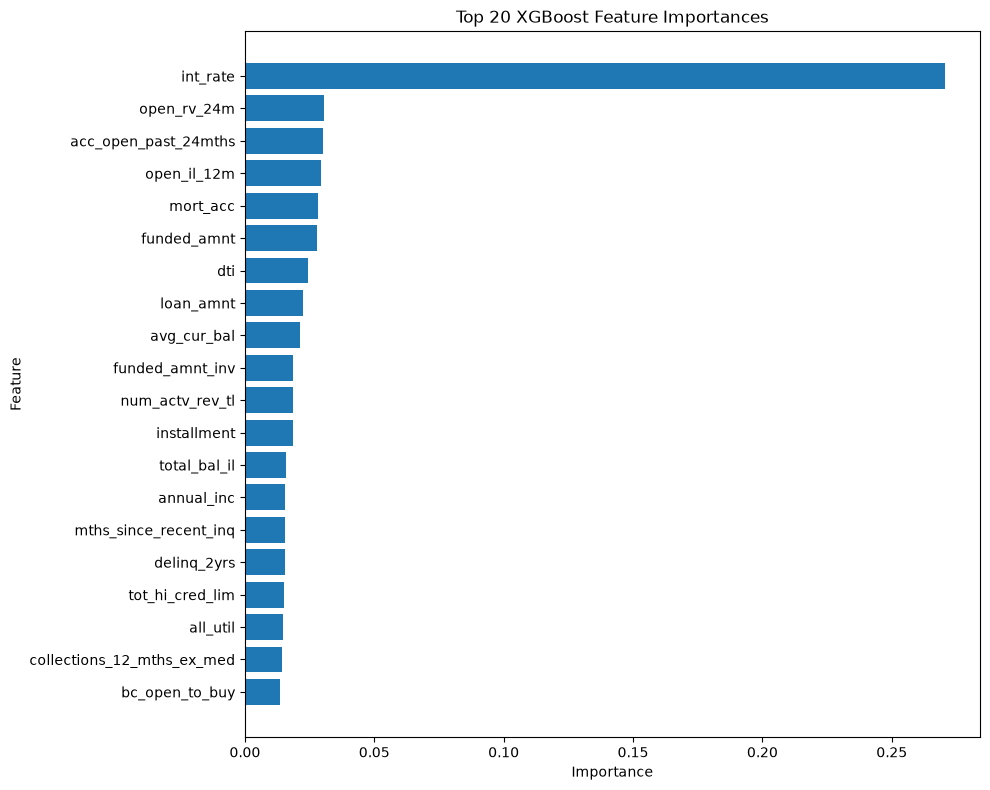


XGBoost feature importance saved successfully.


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --------------------------------------------------
# XGBoost Feature Importance
# --------------------------------------------------

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

# Display top 20 features
print("\nTop 20 XGBoost Features:")
print(
    feature_importance.head(20).to_string(
        index=False
    )
)

# --------------------------------------------------
# Save feature importance
# --------------------------------------------------

os.makedirs("data/processed", exist_ok=True)

feature_importance.to_csv(
    r"C:\Users\HP\Documents\finrisk\notebooks\xgboost_feature_importance.csv",
    index=False
)

# --------------------------------------------------
# Plot top 20 features
# --------------------------------------------------

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Feature Importances")

plt.tight_layout()

plt.savefig(
    r"C:\Users\HP\Documents\finrisk\notebooks\xgboost_feature_importance.png",
    dpi=300
)

plt.show()

print(
    "\nXGBoost feature importance saved successfully."
)

Explain One Individual Loan

In [23]:
import numpy as np

# Select one loan from the test dataset
sample_index = X_test.index[0]

sample_loan = X_test.loc[[sample_index]]
sample_actual = y_test.loc[sample_index]

# Predict risk probability
sample_probability = xgb_model.predict_proba(
    sample_loan
)[0, 1]

# Predict class using threshold 0.5
sample_prediction = int(
    sample_probability >= 0.5
)

print("\nIndividual Loan Explanation")
print("-" * 40)

print(f"Loan index: {sample_index}")
print(f"Actual class: {sample_actual}")
print(f"Risk probability: {sample_probability:.4f}")
print(f"Risk probability: {sample_probability * 100:.2f}%")
print(f"Predicted class: {sample_prediction}")

if sample_prediction == 1:
    print("Prediction: Risky loan")
else:
    print("Prediction: Safe loan")

print("\nFeature values for this loan:")
print(sample_loan.T.to_string())


Individual Loan Explanation
----------------------------------------
Loan index: 263448
Actual class: 0
Risk probability: 0.6357
Risk probability: 63.57%
Predicted class: 1
Prediction: Risky loan

Feature values for this loan:
                               263448
loan_amnt                    35000.00
funded_amnt                  35000.00
funded_amnt_inv              35000.00
int_rate                        16.99
installment                    869.66
policy_code                      1.00
delinq_amnt                      0.00
annual_inc                  130000.00
dti                             15.03
mths_since_rcnt_il              12.00
mths_since_recent_bc            52.00
mths_since_recent_inq           10.00
delinq_2yrs                      1.00
inq_last_6mths                   0.00
open_acc                         7.00
pub_rec                          0.00
revol_bal                     5459.00
revol_util                      42.30
total_acc                       13.00
collections_

In [ ]:
pip install shap

c:\Users\HP\Documents\finrisk\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Preparing SHAP explanation...
SHAP values calculated.


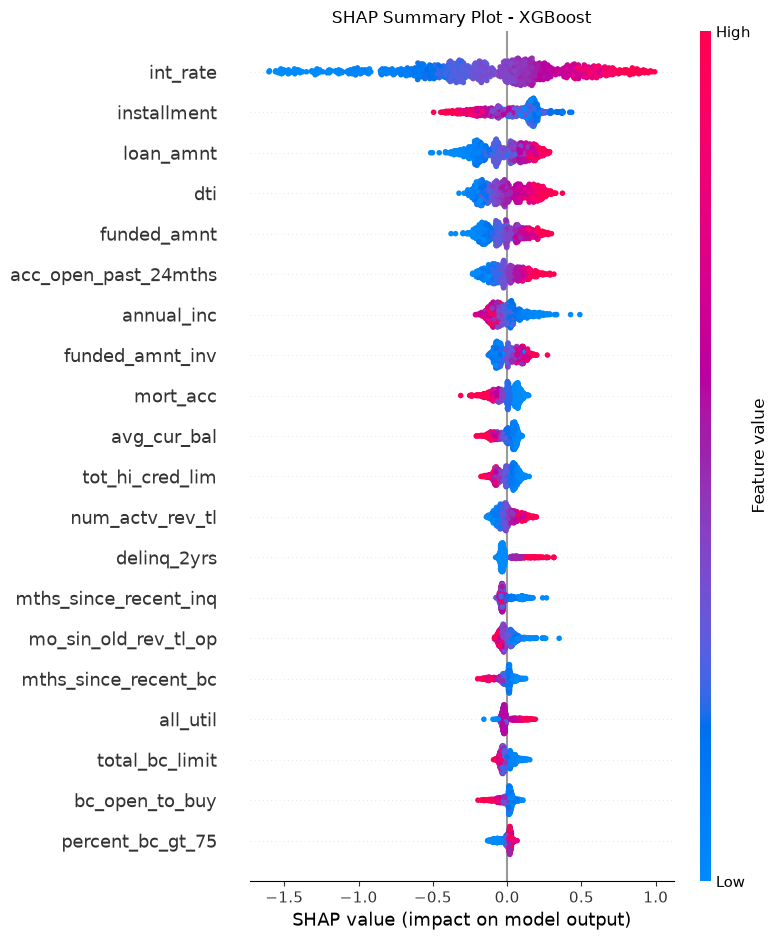

SHAP summary plot saved successfully.


In [26]:
import shap
import matplotlib.pyplot as plt
import os

# --------------------------------------------------
# SHAP Explainability
# --------------------------------------------------

print("\nPreparing SHAP explanation...")

# Use a small sample for explanation
X_shap = X_test.sample(
    n=1000,
    random_state=42
)

# Create SHAP TreeExplainer
explainer = shap.TreeExplainer(
    xgb_model
)

# Calculate SHAP values
shap_values = explainer.shap_values(
    X_shap
)

print("SHAP values calculated.")

# --------------------------------------------------
# SHAP Summary Plot
# --------------------------------------------------

os.makedirs("data/processed", exist_ok=True)

plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Summary Plot - XGBoost"
)

plt.tight_layout()

plt.savefig(
    "data/processed/xgboost_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "SHAP summary plot saved successfully."
)

Local SHAP Explanation for One Loan


Top Features Increasing Risk:
             feature  feature_value  shap_value
            int_rate          16.99    0.465895
         funded_amnt       35000.00    0.286372
           loan_amnt       35000.00    0.266323
     funded_amnt_inv       35000.00    0.181874
         delinq_2yrs           1.00    0.090691
mo_sin_old_rev_tl_op         102.00    0.072909
      total_bc_limit        6600.00    0.066727
           revol_bal        5459.00    0.048889
       num_rev_accts           8.00    0.024318
    total_rev_hi_lim       12900.00    0.020892

Top Features Decreasing Risk:
              feature  feature_value  shap_value
          installment         869.66   -0.161024
          avg_cur_bal       47524.00   -0.129330
 acc_open_past_24mths           2.00   -0.121562
 mths_since_recent_bc          52.00   -0.084368
           annual_inc      130000.00   -0.079881
                  dti          15.03   -0.061498
             mort_acc           2.00   -0.051040
      tot_hi_cred_

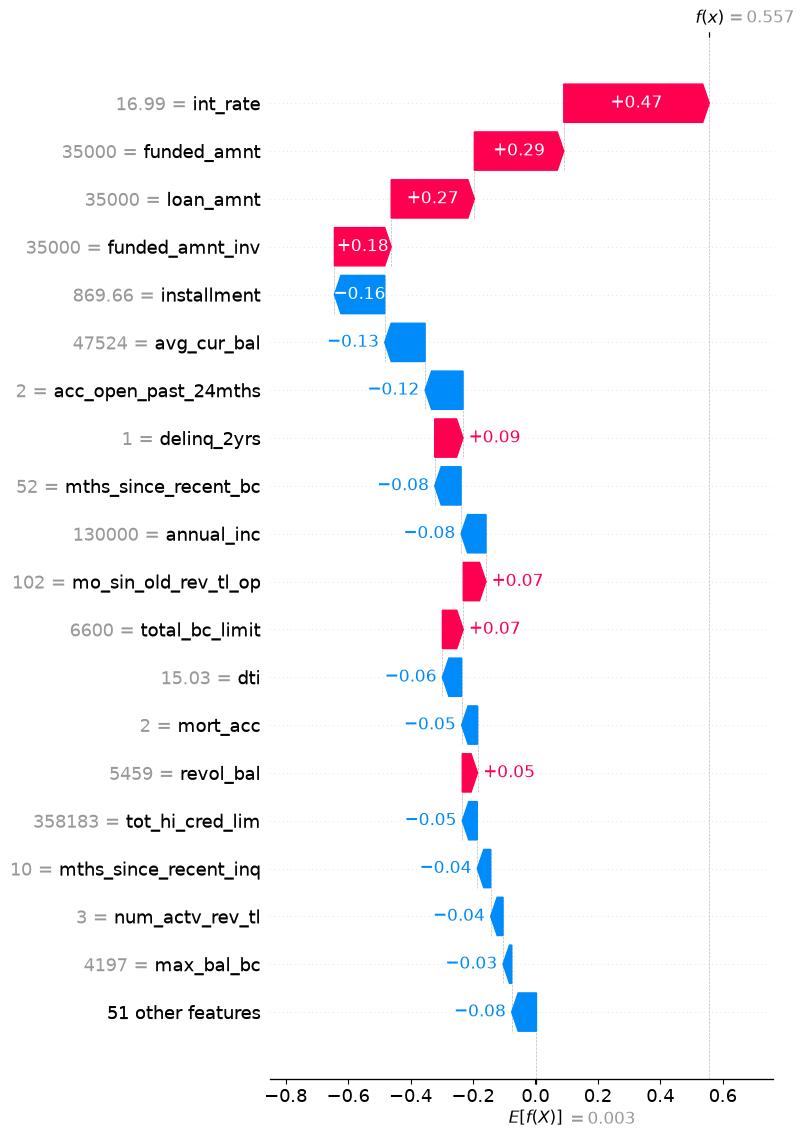


Local SHAP explanation saved successfully.


In [27]:

import pandas as pd
import matplotlib.pyplot as plt
import shap
import os

# Use the same loan index as before
sample_index = 263448

# Select the loan
sample_loan = X_test.loc[[sample_index]]

# Create explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for this loan
sample_shap_values = explainer.shap_values(
    sample_loan
)

# --------------------------------------------------
# Display SHAP contributions
# --------------------------------------------------

local_explanation = pd.DataFrame({
    "feature": sample_loan.columns,
    "feature_value": sample_loan.iloc[0].values,
    "shap_value": sample_shap_values[0]
})

# Largest positive contributions
positive_contributions = local_explanation.sort_values(
    by="shap_value",
    ascending=False
).head(10)

# Largest negative contributions
negative_contributions = local_explanation.sort_values(
    by="shap_value",
    ascending=True
).head(10)

print("\nTop Features Increasing Risk:")
print(
    positive_contributions.to_string(
        index=False
    )
)

print("\nTop Features Decreasing Risk:")
print(
    negative_contributions.to_string(
        index=False
    )
)

# --------------------------------------------------
# Local SHAP waterfall plot
# --------------------------------------------------

os.makedirs("data/processed", exist_ok=True)

shap_explanation = shap.Explanation(
    values=sample_shap_values[0],
    base_values=explainer.expected_value,
    data=sample_loan.iloc[0].values,
    feature_names=sample_loan.columns.tolist()
)

shap.plots.waterfall(
    shap_explanation,
    max_display=20,
    show=False
)

plt.tight_layout()

plt.savefig(
    "data/processed/local_shap_loan_263448.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nLocal SHAP explanation saved successfully."
)

In [28]:
import pandas as pd
import os

# --------------------------------------------------
# Final Model Comparison
# --------------------------------------------------

model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": 0.6602,
        "precision": 0.3257,
        "recall": 0.6474,
        "f1_score": 0.4334,
        "roc_auc": 0.7129,
        "pr_auc": 0.3739
    },
    {
        "model": "Random Forest",
        "accuracy": 0.6530,
        "precision": 0.3227,
        "recall": 0.6629,
        "f1_score": 0.4340,
        "roc_auc": 0.7156,
        "pr_auc": 0.3814
    },
    {
        "model": "XGBoost",
        "accuracy": 0.6610,
        "precision": 0.3316,
        "recall": 0.6779,
        "f1_score": 0.4453,
        "roc_auc": 0.7292,
        "pr_auc": 0.4018
    }
])

print("\nFinal Model Comparison:")
print(
    model_comparison.round(4).to_string(
        index=False
    )
)

os.makedirs("data/processed", exist_ok=True)

model_comparison.to_csv(
    r"C:\Users\HP\Documents\finrisk\notebooks\final_model_comparison.csv",
    index=False
)

print(
    "\nFinal model comparison saved successfully."
)


Final Model Comparison:
              model  accuracy  precision  recall  f1_score  roc_auc  pr_auc
Logistic Regression    0.6602     0.3257  0.6474    0.4334   0.7129  0.3739
      Random Forest    0.6530     0.3227  0.6629    0.4340   0.7156  0.3814
            XGBoost    0.6610     0.3316  0.6779    0.4453   0.7292  0.4018

Final model comparison saved successfully.


In [29]:
import os
import joblib

# Create folders if they do not exist
os.makedirs("models", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

# Save the trained XGBoost model
joblib.dump(xgb_model, r"C:\Users\HP\Documents\finrisk\models\finrisk_xgboost_model.pkl")

# Save the preprocessing pipeline
joblib.dump(preprocessor, r"C:\Users\HP\Documents\finrisk\models\finrisk_preprocessor.pkl")

# Save the feature names used by the model
feature_names = X_train.columns.tolist()

joblib.dump(feature_names, r"C:\Users\HP\Documents\finrisk\models\finrisk_feature_names.pkl")

print("Final XGBoost model saved successfully.")
print("Preprocessor saved successfully.")
print("Feature names saved successfully.")

Final XGBoost model saved successfully.
Preprocessor saved successfully.
Feature names saved successfully.
